# 07 — Query-side noise robustness

How much does retrieval degrade when the **experimental query** spectrum carries
chemical-shift error? Spectrometer referencing, solvent effects and peak-picking all
move ¹³C shifts by a fraction of a ppm in practice, so a method that is only accurate
on pristine peak lists is of limited use.

We add two kinds of synthetic noise to every query and re-run retrieval:

* **Per-peak jitter** — each peak's shift is perturbed independently by `N(0, σ)`
  (models peak-picking / digital resolution).
* **Global offset** — the whole spectrum is shifted by a single `N(0, σ)` draw
  (models referencing / calibration error).

Noise is added to the shift *magnitude* only; the sign (which encodes DEPT multiplicity)
is preserved, since calibration does not turn a CH₂ into a CH. The **candidate pool is
fixed from the clean queries**, so the change in Hits@k isolates ranking robustness
rather than a shifting prefilter recall ceiling.

> All three methods are swept. DEPT-Match (Hungarian) re-aligns all ~64 M query–candidate
> pairs for every noise configuration (~1 min each on 96 cores via fork-inherited globals);
> toggle it with `RUN_HUNGARIAN` in `scripts/exp_noise_run.py`.

## 0 · Imports & configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from dept_similarity.constants import RESULTS_DIR, PROCESSED_DATA_DIR
from dept_similarity.match import get_metrics_at_k
from dept_similarity.prepare import prefilter_pairs_by_peak_overlap
import dept_similarity.experiments as R

FIG_DIR = Path(PROCESSED_DATA_DIR).parent / "figures"
NOISE_DIR = Path(RESULTS_DIR) / "noise_robustness"
DPI = 400

SIGMAS = [0.1, 0.3, 0.5]          # chemical-shift noise levels (ppm)
MODES = ["jitter", "offset"]
SEEDS = list(range(5))            # repeats per (mode, sigma) for error bars
K_VALUES = (1, 3, 10)
REGENERATE = False                # False: load cached summary; True: recompute the sweep

AMBER, SLATE, SAND, GREY = "#D89168", "#4E6E81", "#B08968", "#8A8A8A"  # Gaussian / DEPT-Match / shift-binned (matches Figs S1,S3,S5)
plt.rcParams.update({"font.size": 13, "axes.spines.top": False, "axes.spines.right": False})

## 1 · The noise model

`dept_similarity.experiments.perturb_peaks` implements both modes on a signed-shift spectrum.

In [2]:
import inspect
print(inspect.getsource(R.perturb_peaks))

def perturb_peaks(peaks: np.ndarray, sigma: float, rng: np.random.Generator, mode: str) -> np.ndarray:
    """Add chemical-shift noise to a signed-shift spectrum.

    ``peaks`` encode multiplicity in the sign and shift in the magnitude. Noise is added
    to the *magnitude* only (calibration / solvent effects move a peak's ppm but do not
    change whether a carbon is CH/CH3 vs CH2), so the sign is preserved.

    mode = "jitter"  : each peak shifted independently ~ N(0, sigma)  (peak-picking / resolution)
    mode = "offset"  : whole spectrum shifted by one draw ~ N(0, sigma) (referencing / calibration)
    """
    if sigma <= 0:
        return peaks
    signs = np.sign(peaks)
    signs[signs == 0] = 1.0
    mag = np.abs(peaks).astype(np.float64)
    if mode == "jitter":
        mag = mag + rng.normal(0.0, sigma, size=mag.shape)
    elif mode == "offset":
        mag = mag + rng.normal(0.0, sigma)
    else:
        raise ValueError(f"unknown mode {mode!r}")
    mag = np.clip(mag, 0.0

## 2 · Run the sweep (or load the cached summary)

With `REGENERATE = True` this rebuilds the fixed candidate pool with the peak-overlap
prefilter, encodes each vector library once, and scores every
`(method, mode, σ, seed)` configuration, writing
`data/results/noise_robustness/summary.parquet`. Otherwise the cached summary is loaded.

In [3]:
if REGENERATE:
    lib = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
    q = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")
    lib["signed_shifts"] = lib["signed_shifts"].map(lambda v: np.asarray(v, np.float32))
    q["signed_shifts"] = q["signed_shifts"].map(lambda v: np.asarray(v, np.float32))
    if not (q["compound_id"].str.split("_").str[-1] == q["inchikey14"]).all():
        q["compound_id"] = q["compound_id"] + "_" + q["inchikey14"]

    OPT = Path(RESULTS_DIR) / "optimization"
    GAUSS_SIGMA = float(pd.read_parquet(OPT/"gaussian"/"summary_hits_at_k.parquet")
                        .sort_values("Hits@10 (%)").iloc[-1]["sigma"])
    N_TOTAL = q["compound_id"].nunique()

    pairs = {k: sorted(v) for k, v in prefilter_pairs_by_peak_overlap(q, lib).items()}
    qp = q.set_index("compound_id")["signed_shifts"].to_dict()
    lp = lib.set_index("compound_id")["signed_shifts"].to_dict()
    lib_smiles = lib.set_index("compound_id")["smiles"].to_dict()
    lib_ik = lib.set_index("compound_id")["inchikey"].to_dict()
    query_ids = list(pairs.keys())
    cand_order = sorted({c for v in pairs.values() for c in v})
    cand_index = {c: i for i, c in enumerate(cand_order)}

    def hits(df):
        r = get_metrics_at_k(df, query_spectra_df=q, k_values=K_VALUES, with_inchikey14=True,
                             compute_tanimoto=False, n_total_queries=N_TOTAL)
        return {int(k): float(a) for k, a in zip(r["k"], r["accuracy"])}

    rows = []
    for method in ["gauss_kernel", "ppm_bins_typed"]:
        lib_norm = R.encode_library_vectors(cand_order, lp, method, GAUSS_SIGMA)
        base = hits(R.rank_vector_method(query_ids, qp, pairs, cand_index, lib_norm,
                                         method, GAUSS_SIGMA, lib_smiles, lib_ik))
        for k, a in base.items():
            rows.append({"method": method, "mode": "baseline", "sigma": 0.0, "seed": -1, "k": k, "accuracy": a})
        for mode in MODES:
            for sigma in SIGMAS:
                for seed in SEEDS:
                    rng = np.random.default_rng(seed)
                    ql = {qid: R.perturb_peaks(qp[qid], sigma, rng, mode) for qid in query_ids}
                    h = hits(R.rank_vector_method(query_ids, ql, pairs, cand_index, lib_norm,
                                                  method, GAUSS_SIGMA, lib_smiles, lib_ik))
                    for k, a in h.items():
                        rows.append({"method": method, "mode": mode, "sigma": sigma, "seed": seed, "k": k, "accuracy": a})
        del lib_norm
    NOISE_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_parquet(NOISE_DIR / "summary.parquet", index=False)

summary = pd.read_parquet(NOISE_DIR / "summary.parquet")
print(summary["method"].unique(), "| modes:", summary["mode"].unique(),
      "| sigmas:", sorted(summary["sigma"].unique()))
summary.head()

['gauss_kernel' 'ppm_bins_typed' 'hungarian_match'] | modes: ['baseline' 'jitter' 'offset'] | sigmas: [np.float64(0.0), np.float64(0.1), np.float64(0.3), np.float64(0.5), np.float64(1.0), np.float64(3.0), np.float64(5.0)]


,method,mode,sigma,seed,k,accuracy
0,gauss_kernel,baseline,0.0,-1,1,54.783951
1,gauss_kernel,baseline,0.0,-1,3,65.277778
2,gauss_kernel,baseline,0.0,-1,10,75.000000
3,gauss_kernel,jitter,0.1,0,1,54.629630
4,gauss_kernel,jitter,0.1,0,3,65.277778


## 3 · Robustness figure — Hits@k vs chemical-shift noise

Lines are the mean over the 5 seeds; shaded bands are ±1 s.d. The point at σ = 0 is the
clean baseline.

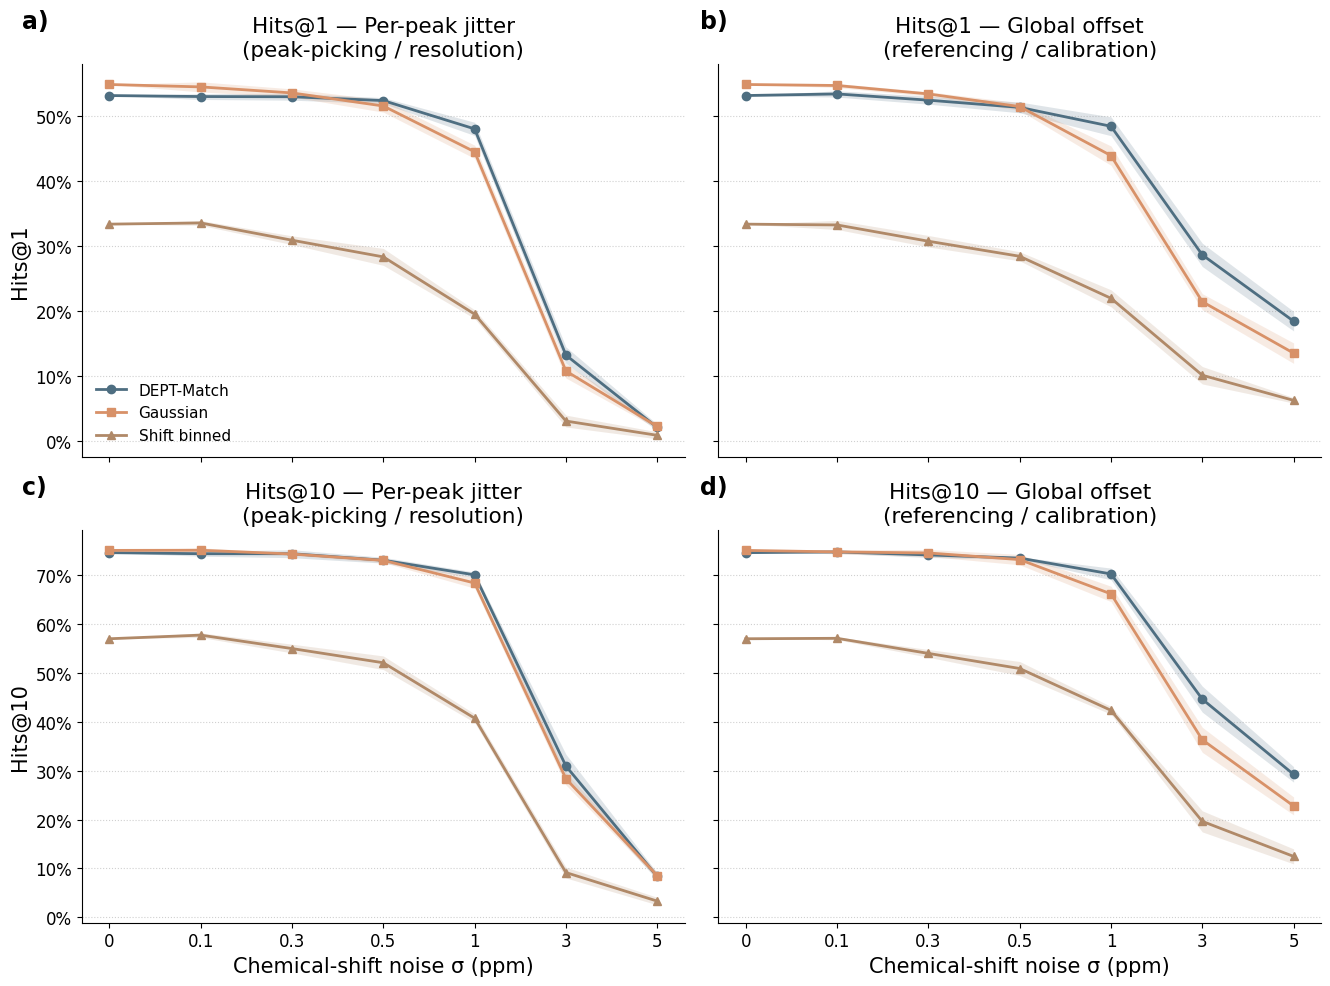

In [4]:
ALL_STYLE = [("hungarian_match", "DEPT-Match", SLATE, "o"),
             ("gauss_kernel", "Gaussian", AMBER, "s"),
             ("ppm_bins_typed", "Shift binned", SAND, "^")]
present = set(summary["method"].unique())
STYLE = [m for m in ALL_STYLE if m[0] in present]
MODE_TITLE = {"jitter": ("Per-peak jitter", "(peak-picking / resolution)"),
              "offset": ("Global offset", "(referencing / calibration)")}
LETTERS = [["a)", "b)"], ["c)", "d)"]]
sigmas = sorted(summary.loc[summary["mode"] != "baseline", "sigma"].unique())
sig_all = [0.0] + list(sigmas)
xpos = np.arange(len(sig_all))  # evenly spaced (ordinal) so the low-sigma detail is readable

fig, axes = plt.subplots(2, 2, figsize=(13.5, 10), sharex=True, sharey="row")
for r, k in enumerate((1, 10)):
    for c, mode in enumerate(("jitter", "offset")):
        ax = axes[r][c]
        for method, label, color, mk in STYLE:
            base = summary[(summary.method == method) & (summary["mode"] == "baseline") & (summary.k == k)]["accuracy"].iloc[0]
            means, stds = [base], [0.0]
            for sig in sigmas:
                sub = summary[(summary.method == method) & (summary["mode"] == mode) & (summary.sigma == sig) & (summary.k == k)]["accuracy"]
                means.append(sub.mean()); stds.append(sub.std())
            means, stds = np.array(means), np.array(stds)
            ax.plot(xpos, means, "-", marker=mk, color=color, lw=2, ms=6, label=label)
            ax.fill_between(xpos, means - stds, means + stds, color=color, alpha=0.18, lw=0)
        line1, line2 = MODE_TITLE[mode]
        ax.set_title(f"Hits@{k} — {line1}\n{line2}", fontsize=15.5, loc="center")
        ax.text(-0.10 if c == 0 else -0.03, 1.14, LETTERS[r][c], transform=ax.transAxes,
                fontsize=17, fontweight="bold", va="top", ha="left")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
        ax.set_xticks(xpos)
        ax.set_xticklabels([f"{s:g}" for s in sig_all])
        ax.tick_params(labelsize=12)
        ax.grid(axis="y", ls=":", color=GREY, alpha=0.4)
        if r == 1:
            ax.set_xlabel("Chemical-shift noise σ (ppm)", fontsize=15)
        if c == 0:
            ax.set_ylabel(f"Hits@{k}", fontsize=15)
        else:
            ax.tick_params(labelleft=False)  # shared y within the row → drop redundant ticks
axes[0][0].legend(frameon=False, fontsize=11, loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "noise_robustness.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 4 · Retained accuracy summary

In [5]:
for method, label, *_ in STYLE:
    base = summary[(summary.method == method) & (summary["mode"] == "baseline") & (summary.k == 10)]["accuracy"].iloc[0]
    parts = [f"{label:>12}: base {base:.1f}%"]
    for mode in ("jitter", "offset"):
        for sig in sigmas:
            m = summary[(summary.method == method) & (summary["mode"] == mode) & (summary.sigma == sig) & (summary.k == 10)]["accuracy"].mean()
            parts.append(f"{mode[:3]}σ{sig}={m:.1f}({100*m/base:.0f}%)")
    print("  ".join(parts))

  DEPT-Match: base 74.5%  jitσ0.1=74.3(100%)  jitσ0.3=74.3(100%)  jitσ0.5=73.0(98%)  jitσ1.0=70.0(94%)  jitσ3.0=30.9(41%)  jitσ5.0=8.4(11%)  offσ0.1=74.7(100%)  offσ0.3=74.1(99%)  offσ0.5=73.4(99%)  offσ1.0=70.2(94%)  offσ3.0=44.6(60%)  offσ5.0=29.2(39%)
    Gaussian: base 75.0%  jitσ0.1=75.0(100%)  jitσ0.3=74.3(99%)  jitσ0.5=73.0(97%)  jitσ1.0=68.3(91%)  jitσ3.0=28.3(38%)  jitσ5.0=8.5(11%)  offσ0.1=74.7(100%)  offσ0.3=74.5(99%)  offσ0.5=73.1(97%)  offσ1.0=66.1(88%)  offσ3.0=36.3(48%)  offσ5.0=22.8(30%)
Shift binned: base 56.9%  jitσ0.1=57.7(101%)  jitσ0.3=54.9(96%)  jitσ0.5=52.0(91%)  jitσ1.0=40.7(71%)  jitσ3.0=9.2(16%)  jitσ5.0=3.3(6%)  offσ0.1=57.0(100%)  offσ0.3=54.0(95%)  offσ0.5=50.9(89%)  offσ1.0=42.3(74%)  offσ3.0=19.6(34%)  offσ5.0=12.5(22%)
